In [ ]:
CMAKE_ARGS="-DLLAMA_METAL=on"
!pip install rank_bm25
# !pip install faiss-gpu-cu12 # *
!pip install faiss-cpu # if * doesnt work locally
!pip install llama-cpp-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.4/512.4 kB 593.3 kB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached langchain_text_splitters-1.1.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached uuid_utils-0.14.1-cp39-abi3-macosx_10_12_x86_64.macosx_11_0_arm64.macosx_10_12_universal2.whl.metadata (4.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 510.5 kB/s eta 0:00:0000:010:01
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
Using cached langchain_text_splitters-1.1.1-py3-none-any.whl (35 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 kB 1.8 MB/s eta 0:00:0000:0100:01
Using cached jsonpatch-1.33-py2.py3-none-any.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.2/360.2 kB 1.4 MB/s eta 0:00:00a 0:00:01
Using cached uuid_utils-0.14.1-cp39-abi3-macosx_10

In [1]:
import os

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [ ]:
from sentence_transformers import SentenceTransformer
import sentence_transformers.losses as losses
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from langchain_text_splitters import RecursiveCharacterTextSplitter
import faiss
import numpy as np
from rank_bm25 import BM25Okapi
import re
from huggingface_hub import login

import json
from typing import Literal, Callable
import copy
import datetime
import traceback
import matplotlib.pyplot as plt
from llama_cpp import Llama
import numpy as np

import numpy as np


In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 60
print(f"Используем устройство: {DEVICE}")

Используем устройство: cpu


In [ ]:
COLAB_HUGGING_FACE_ACCESS_TOKEN = "" # your token
login(token=COLAB_HUGGING_FACE_ACCESS_TOKEN)

In [7]:
class BM25Model:
    def __init__(self, chunk_list: list):
        text_chunk_list = [chunk['text'] for chunk in chunk_list]
        token_list = []
        for chunk in text_chunk_list:
            word_list = re.findall(r'\w+', chunk.lower())
            token_list.append(word_list)
        self.model = BM25Okapi(token_list)


    def search(self, question: str, k: int) -> tuple[torch.Tensor, torch.Tensor]:
        tokenized_query = re.findall(r'\w+', question.lower())
        score_list = self.model.get_scores(tokenized_query)
        # TODO: dont like the copy
        index_list = torch.tensor(np.argsort(score_list)[-k:][::-1].copy())
        return index_list, torch.tensor(score_list)[index_list]

In [ ]:
class DenseModel:
    def __init__(self, chunk_list: list, model_name="deepvk/USER2-small", device: Literal['cpu', 'cuda', 'mps']='cuda'):
        self.model = SentenceTransformer(model_name, device=device)
        text_chunk_list = [chunk['text'] for chunk in chunk_list]
        self.embedding_list = self.model.encode(
            text_chunk_list,
            prompt_name="search_document",
            show_progress_bar=True,
            batch_size=BATCH_SIZE
        )
        faiss.normalize_L2(self.embedding_list)
        self.index = faiss.IndexFlatIP(self.embedding_list.shape[1])
        self.index.add(self.embedding_list.astype('float32')) # type: ignore


    def search(self, question: str, k: int) -> tuple[torch.Tensor, torch.Tensor]:
        query_embedding = self.model.encode([question], prompt_name="search_query")
        faiss.normalize_L2(query_embedding)
        scores, indices = self.index.search(query_embedding.astype('float32'), k) # type: ignore
        return torch.tensor(indices[0]), torch.tensor(scores[0])

In [9]:
class TeacherRetrieverPool(nn.Module):
    def __init__(self, teacher_amount=2, top_k=12, rrf_K=60):
        super().__init__()
        self.RRF_K = rrf_K
        self.top_k = top_k
        self.total_teacher_amount = teacher_amount
        self.teacher_model_dict = {}
        self.weight_tensor = nn.Parameter(torch.ones(teacher_amount))


    def forward(
        self,
        query_data_batch: list[tuple[str, torch.Tensor, torch.Tensor]] # [(str, index_tensor[current_teacher_amount, top_k], ranking_tensor[current_teacher_amount, top_k])]
    ) -> tuple[list[str], torch.Tensor]: # (list of query, positive_document_index_tensor)
        device = next(self.parameters()).device
        batch_size = len(query_data_batch)
        query_list = []    
        fuse_ranked_index_tensor_list = []

        for query_data in query_data_batch:
            query_list.append(query_data[0])
            ranked_index_tensor = self.get_fuse_ranked_index_tensor(query_data[1], query_data[2])
            fuse_ranked_index_tensor_list.append(ranked_index_tensor)
        fused_ranked_index_batch = torch.stack(fuse_ranked_index_tensor_list)  # [batch, top_k]
        
        positive_document_position_tensor = torch.randint(0, 5, (batch_size,))
        positive_document_index_tensor = fused_ranked_index_batch[torch.arange(batch_size), positive_document_position_tensor]
        return query_list, positive_document_index_tensor.to(device)


    def add_teacher(self, teacher_name: str, teacher_model):
        if len(self) < self.total_teacher_amount:
            self.teacher_model_dict[teacher_name] = teacher_model


    def get_index_and_ranking_tensor(self, question_list: list[str]) -> tuple[torch.Tensor, torch.Tensor]:
        index_tensor = torch.zeros((len(question_list), self.total_teacher_amount, self.top_k), dtype=torch.long)
        ranking_tensor = torch.zeros((len(question_list), self.total_teacher_amount, self.top_k))
        for question_index, question in enumerate(question_list):
            for teacher_index, (_, teacher_model) in enumerate(self.teacher_model_dict.items()):
                teacher_index_tensor, teacher_score_tensor = teacher_model.search(question, self.top_k)
                index_tensor[question_index, teacher_index] = teacher_index_tensor
                ranking_tensor[question_index, teacher_index] = teacher_score_tensor
        return index_tensor, ranking_tensor


    # ranking_tensor shape is [current_teacher_amount, top_k]
    def get_fuse_ranked_index_tensor(self, index_tensor: torch.Tensor, ranking_tensor: torch.Tensor) -> torch.Tensor:
        teacher_weight_tensor = self.weight_tensor[:index_tensor.size(0)].view(-1, 1)  # [teacher_amount, 1]
        rrf_score_tensor = teacher_weight_tensor / (self.RRF_K + ranking_tensor)
        flat_index_tensor = index_tensor.flatten()       # [teacher_amount*top_k]
        flat_score_tensor = rrf_score_tensor.flatten()         # [teacher_amount*top_k]
        fused_score_tensor = torch.zeros(int(flat_index_tensor.max().item() + 1), dtype=torch.float)
        fused_score_tensor = fused_score_tensor.scatter_add(0, flat_index_tensor, flat_score_tensor)
        sorted_document_index_tensor = torch.argsort(fused_score_tensor, descending=True)
        return sorted_document_index_tensor
    

    def __len__(self) -> int:
        return len(self.teacher_model_dict)


In [10]:
class MultiNegativeLoss(nn.Module):
    def __init__(self, encoder, temperature=0.05):
        super().__init__()
        self.encoder = encoder
        self.temperature = temperature


    def forward(self, sentence_features, labels=None):
        query_features, positive_features = sentence_features
        query_embeddings = self.encoder(query_features)["sentence_embedding"] # [B, D]
        pos_embeddings   = self.encoder(positive_features)["sentence_embedding"]
        query_embeddings = F.normalize(query_embeddings, dim=1)
        pos_embeddings   = F.normalize(pos_embeddings, dim=1)
        scores = torch.matmul(query_embeddings, pos_embeddings.T) / self.temperature
        labels = torch.arange(scores.size(0), device=scores.device)
        return F.cross_entropy(scores, labels)


In [11]:
class PovaryoshkaRetriever(nn.Module):
  def __init__(
    self,
    document_list: list[str],
    teacher_retriever_pool: TeacherRetrieverPool,
    device: Literal['cpu', 'cuda', 'mps'] = 'cuda',
    encoder_name="deepvk/USER2-small",
    dtype="float32",
    temperature=0.05,
    matryoshka_dims=[384, 256, 128],
    nlist=100
  ):
    super().__init__()
    self.temperature = temperature
    self.document_list = document_list
    self.retriever_index = None
    self.DTYPE = dtype
    self.encoder = SentenceTransformer(encoder_name, device=device, model_kwargs={"dtype": dtype})
    base_encoder_loss = MultiNegativeLoss(self.encoder, temperature)
    self.encoder_loss = losses.MatryoshkaLoss(
      self.encoder,
      base_encoder_loss,
      matryoshka_dims
    )
    self.teacher_retriever_pool = teacher_retriever_pool
    self.NLIST = nlist


  def forward(
    self,
    batch_query_data: list[tuple[str, torch.Tensor, torch.Tensor]] # [(str, index_tensor[current_teacher_amount, top_k], ranking_tensor[current_teacher_amount, top_k])]
  ) -> torch.Tensor:
    assert self.document_list is not None, "Firstly, initialize document_list field"
    encoder_device = next(self.encoder.parameters()).device
    query_list, positive_chunk_index_tensor = self.teacher_retriever_pool(batch_query_data)
    positive_chunk_list = []

    for positive_chunk_index in positive_chunk_index_tensor:
      positive_chunk_list.append(
        self.document_list[positive_chunk_index.item()]
      )

    query_features = self.to_device(
      self.encoder.tokenize(query_list), encoder_device
    )
    positive_features = self.to_device(
      self.encoder.tokenize(positive_chunk_list), encoder_device
    )
    return self.encoder_loss(
      sentence_features=[query_features, positive_features],
      labels=None
    )


  def to_device(self, features, device):
    return {k: v.to(device) for k, v in features.items()}


  def get_encoded_query_tensor(
    self,
    query_list: list[str],
    is_normalize=True
  ) -> torch.Tensor:
    self.eval()
    with torch.inference_mode():
      return self._get_encoded_text_tensor(query_list, True, is_normalize)


  def get_encoded_document_tensor(
    self,
    document_list: list[str],
    is_normalize=True
  ) -> torch.Tensor:
    self.eval()
    with torch.inference_mode():
      return self._get_encoded_text_tensor(document_list, is_normalize)
      

  def _get_encoded_text_tensor(
    self,
    text_list: list[str],
    is_query=False,
    is_normalize=True
  ) -> torch.Tensor:
    embedding_text_list = self.encoder.encode(
      text_list,
      prompt_name="search_query" if is_query else "search_document",
      convert_to_tensor=True,
      truncate_dim=384
    )
    if is_normalize:
      embedding_text_list = F.normalize(embedding_text_list, dim=1)
    return embedding_text_list


  def build_index(self):
    self.eval()
    with torch.inference_mode():
      # TODO: Check about type
      embedding_list = self._get_encoded_text_tensor(self.document_list).cpu().numpy().astype('float32') 
    embedding_list = np.ascontiguousarray(embedding_list)
    embedding_dimension = embedding_list.shape[1]
    retriever_index = faiss.IndexFlatIP(embedding_dimension)
    retriever_index.add(embedding_list) # type: ignore
    self.retriever_index = retriever_index


  def search(
    self,
    query_list: list[str],
    top_k=15
  ) -> list[list[int]]:
    assert self.retriever_index is not None, "Firstly call build_index()"
    self.eval()
    with torch.inference_mode():
      query_embedding_list = self._get_encoded_text_tensor(
        query_list,
        True
      ).cpu().numpy().astype('float32')
    _, indices_list = self.retriever_index.search(query_embedding_list, top_k) # type: ignore
    return indices_list


  def save(self, path: str):
    self.encoder.save(path)


  def load(self, path: str):
    self.encoder = SentenceTransformer(path)


In [ ]:
input_filename = 'train_pruned_recipe_chunks_with_questions_1.json'
with open(input_filename, 'r', encoding='utf-8') as f:
    pruned_train_chunk_list = json.load(f)
print(f"Загружено {len(pruned_train_chunk_list)} чанков из {input_filename}")


Сохранено 406 чанков в pruned_recipe_chunks_with_questions_1.json


In [ ]:
input_filename = 'eval_pruned_recipe_chunks_with_questions_2.json'
with open(input_filename, 'r', encoding='utf-8') as f:
    pruned_eval_chunk_list = json.load(f)
print(f"Загружено {len(pruned_eval_chunk_list)} чанков из {input_filename}")


Сохранено 173 чанков в pruned_recipe_chunks_with_questions_2.json


In [ ]:
pruned_train_chunk_list = pruned_train_chunk_list[:400]
pruned_eval_chunk_list = pruned_eval_chunk_list[:160]
pruned_common_chunk_list = pruned_train_chunk_list + pruned_eval_chunk_list
common_document_list = [chunk['text'] for chunk in pruned_common_chunk_list]

In [ ]:
teacher_retriever_pool = TeacherRetrieverPool(1, top_k=5)
teacher_retriever_pool.add_teacher('bm25', BM25Model(pruned_common_chunk_list))
teacher_retriever_pool.add_teacher('dense', DenseModel(pruned_common_chunk_list, device='mps'))


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Compiling the model with `torch.compile` and using a `torch.mps` device is not supported. Falling back to non-compiled mode.


In [ ]:
train_ranked_recipe_chunks_filename = 'train_ranked_recipe_chunks_1.pth'

# TODO: Think do we need here to add context ?
train_ranked_chunk_list = []
for train_chunk in pruned_train_chunk_list:
    # TODO: not only the first
    first_question = f"Контекст: {train_chunk['recipe_name']}\n\n{train_chunk['questions'][0]}"
    train_chunk['questions'][0] = first_question
    index_tensor, ranked_index_tensor = teacher_retriever_pool.get_index_and_ranking_tensor([first_question])
    train_chunk['index_tensors'] = index_tensor
    train_chunk['ranking_tensors'] = ranked_index_tensor
    train_ranked_chunk_list.append(train_chunk)
torch.save(train_ranked_chunk_list, train_ranked_recipe_chunks_filename)


In [ ]:
eval_ranked_recipe_chunks_filename = 'eval_ranked_recipe_chunks_1.pth'

eval_ranked_chunk_list = []
for eval_chunk in pruned_eval_chunk_list:
    # TODO: not only the first
    first_question = f"Контекст: {eval_chunk['recipe_name']}\n\n{eval_chunk['questions'][0]}"
    eval_chunk['questions'][0] = first_question
    index_tensor, ranked_index_tensor = teacher_retriever_pool.get_index_and_ranking_tensor([first_question])
    eval_chunk['index_tensors'] = index_tensor
    eval_chunk['ranking_tensors'] = ranked_index_tensor
    eval_ranked_chunk_list.append(eval_chunk)
torch.save(eval_ranked_chunk_list, eval_ranked_recipe_chunks_filename)

In [ ]:
train_ranked_chunk_list = torch.load(train_ranked_recipe_chunks_filename)
for train_chunk in train_ranked_chunk_list:
    train_chunk['index_tensors'] = train_chunk['index_tensors'].to(DEVICE)
    train_chunk['ranking_tensors'] = train_chunk['ranking_tensors'].to(DEVICE)
print(len(train_ranked_chunk_list))

400


In [ ]:
eval_ranked_chunk_list = torch.load(eval_ranked_recipe_chunks_filename)
for eval_chunk in eval_ranked_chunk_list:
    eval_chunk['index_tensors'] = eval_chunk['index_tensors'].to(DEVICE)
    eval_chunk['ranking_tensors'] = eval_chunk['ranking_tensors'].to(DEVICE)
print(len(eval_ranked_chunk_list))

160


In [19]:
class RetrieverDataset(Dataset):
    def __init__(self, ranked_chunk_list):
        self.ranked_chunk_list = ranked_chunk_list


    def __len__(self) -> int:
        return len(self.ranked_chunk_list)

    # TODO
    def __getitem__(self, index: int) -> tuple[str, torch.Tensor, torch.Tensor]:
        ranked_chunk = self.ranked_chunk_list[index]
        return ranked_chunk['questions'][0], ranked_chunk['index_tensors'][0], ranked_chunk['ranking_tensors'][0]


In [20]:
def create_povaryoshka_retriever_fn(teacher_retriever_pool: TeacherRetrieverPool):
    current_epoch_number = 0

    def povaryoshka_retriever_collate_fn(
        query_data_batch: list[tuple[str, torch.Tensor, torch.Tensor]] # [(str, index_tensor[teacher_amount, top_k], ranking_tensor[teacher_amount, top_k])]
    ) -> list[tuple[str, torch.Tensor, torch.Tensor]]: # [(str, index_tensor[current_teacher_amount, top_k], ranking_tensor[current_teacher_amount, top_k])]
        teacher_retriever_amount = 1 if current_epoch_number == 0 else len(teacher_retriever_pool)
        updated_query_data_batch = []
        for query_data in query_data_batch:
            updated_query_data_batch.append(
                (query_data[0], query_data[1][:teacher_retriever_amount], query_data[2][:teacher_retriever_amount])
            )
        return updated_query_data_batch
    
    def set_current_epoch_number(value: int):
        nonlocal current_epoch_number
        current_epoch_number = value
    
    return povaryoshka_retriever_collate_fn, set_current_epoch_number


In [21]:
def compute_recall_at_k(
    retriever_model: PovaryoshkaRetriever,
    query_list: list[str],
    true_index_list: list[int],
    k=5
) -> float:
    retriever_model.eval()
    correct_amount = 0
    with torch.no_grad():
        retrieved_indices_list = retriever_model.search(query_list, top_k=k)
        for i in range(len(query_list)):
            if true_index_list[i] in retrieved_indices_list[i]:
                correct_amount += 1
    return correct_amount / len(query_list)


def copy_data_to_device(data, device):
  if torch.is_tensor(data):
    return data.to(device)
  elif isinstance(data, (list, tuple)):
    return [copy_data_to_device(elem, device) for elem in data]
  return data


def loss_plot(losses: list[float]):
  plt.plot(np.arange(len(losses)), losses)
  plt.title('Losses')
  plt.xlabel("epoch")
  plt.show()


def retriever_train_loop(
    retriever_model: PovaryoshkaRetriever,
    set_current_epoch_number: Callable[[int], None],
    train_dataloader,
    eval_dataloader,
    lr=1e-4,
    epoch_amount=10,
    device: Literal['cuda', 'cpu', 'mps']='cuda',
    l2_reg_alpha=0,
    optimizer_ctor=None,
    lr_scheduler_ctor=None,
    early_stopping_patience=10,
    k=5
):
    if optimizer_ctor is None:
        optimizer = torch.optim.Adam(retriever_model.parameters(), lr=lr, weight_decay=l2_reg_alpha)
    else:
        optimizer = optimizer_ctor(retriever_model.parameters(), lr=lr)

    if lr_scheduler_ctor is not None:
        lr_scheduler = lr_scheduler_ctor(optimizer)

    best_eval_loss = float('inf')
    retriever_model = retriever_model.to(device)
    best_retriever_model = copy.deepcopy(retriever_model)
    retriever_model.train()
    loss_list = []

    for epoch_index in range(epoch_amount):
        try:
            set_current_epoch_number(epoch_index)
            epoch_start = datetime.datetime.now()
            print(f'Эпоха {epoch_index}')
            retriever_model.train()
            mean_train_loss = 0
            train_batches_n = 0
            for train_batch in train_dataloader:
                train_batch = copy_data_to_device(train_batch, device)
                train_loss = retriever_model(train_batch)
                retriever_model.zero_grad()
                train_loss.backward()
                optimizer.step()
                mean_train_loss += train_loss.item()
                train_batches_n += 1

            mean_train_loss /= train_batches_n
            loss_list.append(mean_train_loss)
            print('Эпоха: {} итераций, {:0.2f} сек'.format(train_batches_n,
                                                           (datetime.datetime.now() - epoch_start).total_seconds()))

            if eval_dataloader is None:
                if lr_scheduler is not None:
                    lr_scheduler.step(mean_train_loss)
                continue

            retriever_model.eval()
            mean_eval_loss = 0
            eval_batches_n = 0
            eval_data = []
            with torch.no_grad():
                for eval_batch in eval_dataloader:
                    eval_batch = copy_data_to_device(eval_batch, device)
                    eval_data.extend(eval_batch)
                    eval_loss = retriever_model(eval_batch)
                    mean_eval_loss += float(eval_loss)
                    eval_batches_n += 1

            mean_eval_loss /= eval_batches_n
            print(f'Среднее значение функции потерь на валидации {mean_eval_loss}')

            # Move to another place maybe   
            retriever_model.build_index()
            with torch.no_grad():
                _, positive_document_index_tensor = retriever_model.teacher_retriever_pool(eval_data)
            recall_at_k = compute_recall_at_k(
                retriever_model,
                [chunk[0] for chunk in eval_data],
                positive_document_index_tensor.cpu().numpy().tolist(),
                k=k
            )
            print(f'Total query amount: {len(eval_data)}')
            print(f'Recall@{k}: {recall_at_k}')
                

            if mean_eval_loss < best_eval_loss:
                best_epoch_index = epoch_index
                best_eval_loss = mean_eval_loss
                best_retriever_model = copy.deepcopy(retriever_model)
                print('Новая лучшая модель!')
                torch.save(best_retriever_model.state_dict(), 'povaryoshka_retriever_model_weights.pth')
                print("Модель сохранена!")
            elif epoch_index - best_epoch_index > early_stopping_patience:
                print('Модель не улучшилась за последние {} эпох, прекращаем обучение'.format(
                    early_stopping_patience))
                break
            print()
        except KeyboardInterrupt:
            print('Досрочно остановлено пользователем')
            break
        except Exception as ex:
            print(f'Ошибка при обучении: {ex}\n{traceback.format_exc()}')
            break
    loss_plot(loss_list)
    if eval_dataloader is None:
        return retriever_model, None
    return best_retriever_model, best_eval_loss
    

Эпоха 0
Эпоха: 7 итераций, 91.34 сек
Среднее значение функции потерь на валидации 1.5198358694712322
Total query amount: 160
Recall@5: 0.55625
Новая лучшая модель!
Модель сохранена!

Эпоха 1
Эпоха: 7 итераций, 97.70 сек
Среднее значение функции потерь на валидации 1.19520898660024
Total query amount: 160
Recall@5: 0.5875
Новая лучшая модель!
Модель сохранена!

Эпоха 2
Эпоха: 7 итераций, 101.82 сек
Среднее значение функции потерь на валидации 1.1536296606063843
Total query amount: 160
Recall@5: 0.6125
Новая лучшая модель!
Модель сохранена!

Эпоха 3
Эпоха: 7 итераций, 90.47 сек
Среднее значение функции потерь на валидации 0.9823375344276428
Total query amount: 160
Recall@5: 0.65
Новая лучшая модель!
Модель сохранена!

Эпоха 4
Эпоха: 7 итераций, 94.70 сек
Среднее значение функции потерь на валидации 0.9285711248715719
Total query amount: 160
Recall@5: 0.70625
Новая лучшая модель!
Модель сохранена!

Эпоха 5
Эпоха: 7 итераций, 102.95 сек
Среднее значение функции потерь на валидации 0.939610

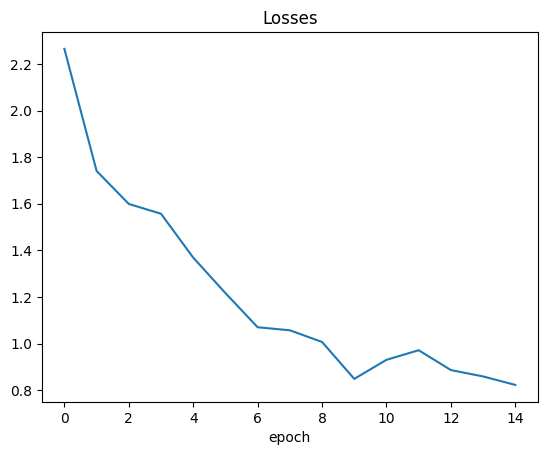

In [ ]:
train_dataset = RetrieverDataset(train_ranked_chunk_list)
povaryoshka_retriever_collate_fn, set_current_epoch_number = create_povaryoshka_retriever_fn(
  teacher_retriever_pool
)
train_dataloader = DataLoader(
  train_dataset,
  batch_size=BATCH_SIZE,
  shuffle=True,
  collate_fn=povaryoshka_retriever_collate_fn,
  num_workers=0
)
eval_dataset = RetrieverDataset(eval_ranked_chunk_list)
eval_dataloader = DataLoader(
  eval_dataset,
  batch_size=BATCH_SIZE,
  shuffle=True,
  collate_fn=povaryoshka_retriever_collate_fn,
  num_workers=0
)



llm_model = PovaryoshkaRetriever(
  common_document_list,
  teacher_retriever_pool,
  temperature=0.1,
  dtype='float32',
  nlist=1,
  device=DEVICE,
  matryoshka_dims=[384]
)

scheduler = lambda optim: \
    torch.optim.lr_scheduler.ReduceLROnPlateau(optim, patience=3, factor=0.43)
trained_retriever_model, _ = retriever_train_loop(
  llm_model,
  set_current_epoch_number,
  train_dataloader,
  eval_dataloader,
  lr_scheduler_ctor=scheduler,
  epoch_amount=15,
  device=DEVICE
)


In [20]:
llm_model = Llama(
    model_path="/Users/philippplotnikov/WorkingSpace/Coding/models/Qwen3-8B-Q4_K_M-Instruct.gguf",
    n_ctx=4096,        # контекст
    n_threads=8,       # под CPU
    n_gpu_layers=40,    # для M1 (ускорение через Metal)
    verbose=False
)

llama_context: n_ctx_seq (4096) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


In [ ]:
def generate(prompt, max_new_tokens=1024, temperature=0.4, top_k=50, top_p=0.9, repeat_penalty=1.3, stop_tokens=None):
    output = llm_model(
        prompt,
        max_tokens=max_new_tokens,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        repeat_penalty=repeat_penalty,
        stop=stop_tokens
    )

    # Берём только сгенерированный текст
    text = output["choices"][0]["text"] # type: ignore

    # Обрезаем до первого stop-токена, если он есть
    if stop_tokens:
        for stop in stop_tokens:
            if stop in text:
                text = text.split(stop)[0]

    return text.strip()

In [22]:
class ContextManager:
    def __init__(self, max_history=5):
        self.user_contexts = {}  # user_id → список компактных документов
        self.max_history = max_history

    def add_context(self, user_id: str, doc_text: str):
        if user_id not in self.user_contexts:
            dish = generate(f"""
Ты — ассистент, который определяет название блюда из текста.

ПРАВИЛА:
- Ответь ТОЛЬКО названием блюда.
- Не добавляй пояснений.
- Не изменяй название блюда.
- Если блюдо не указано явно — ответь "Нет".
- Если блюд несколько — выбери основное (о котором больше всего информации).

Пример:

Текст:
Обсуждается Пирог Киш Лорен с томатами и моцареллой: тесто из муки, сливочного масла, сметаны и соли нужно охладить 1 час; пользователь интересуется начинкой.

Ответ:
Пирог Киш Лорен с томатами и моцареллой
###END###

Теперь твой текст:

Текст:
{doc_text}

Ответ:
""", stop_tokens=["###END###"])
            self.user_contexts[user_id] = {
                "summary": doc_text,
                "dish": dish
            }
            return
        prev_context = self.user_contexts[user_id]
        compact_prompt = f"""
Ты — ассистент, который обновляет краткий контекст диалога для хранения в памяти пользователя.

ПРАВИЛА:
- Сохраняй только факты из текста.
- Не добавляй ничего нового, чего нет в тексте.
- Удаляй дубли и устаревшую информацию.
- Перефразируй и сжимай текст, делай его кратким и понятным.
- Сохраняй ключевые данные: названия блюд, ингредиенты, действия, числа.
- Итог должен быть коротким (1–3 предложения).

Пример:

Текущий текст:
Пользователь обсуждает Пирог Киш Лорен с томатами и моцареллой. Для теста используются мука, сливочное масло, сметана и соль.

Новое сообщение:
Пользователь уточнил, что тесто нужно убрать в холодильник на 1 час и спрашивает про начинку.

Компактная версия:
Обсуждается Пирог Киш Лорен с томатами и моцареллой: тесто из муки, сливочного масла, сметаны и соли нужно охладить 1 час; пользователь интересуется начинкой.
###END###

Теперь твой запрос:

Текущий текст:
{prev_context["summary"]}

Новое сообщение:
{doc_text}

Компактная версия:
"""
        compact_doc = generate(compact_prompt, stop_tokens=["###END###"])

        dish = generate(f"""
Ты — ассистент, который определяет название блюда из текста.

ПРАВИЛА:
- Ответь ТОЛЬКО названием блюда.
- Не добавляй пояснений.
- Не изменяй название блюда.
- Если блюдо не указано явно — ответь "Нет".
- Если блюд несколько — выбери основное (о котором больше всего информации).

Пример:

Текст:
Обсуждается Пирог Киш Лорен с томатами и моцареллой: тесто из муки, сливочного масла, сметаны и соли нужно охладить 1 час; пользователь интересуется начинкой.

Ответ:
Пирог Киш Лорен с томатами и моцареллой
###END###

Теперь твой текст:

Текст:
{compact_doc}

Ответ:
""", stop_tokens=["###END###"])

        self.user_contexts[user_id] = {
            "summary": compact_doc,
            "dish": dish
        }


    def get_context(self, user_id: str) -> str:
        state = self.user_contexts.get(user_id, {})
        return f"""
Тема: {state.get("dish")}
Контекст: {state.get("summary")}
"""

In [23]:
def rewrite_query_llm(query, context_manager: ContextManager, user_id: str):
    context = context_manager.get_context(user_id)

    prompt = f"""
Ты помощник-кулинар. Твоя задача — переписать запрос пользователя для поиска по базе знаний так, чтобы он был:

- кратким,
- точным,
- максимально информативным,
- учитывал контекст диалога.

Правила:
- Не используй ссылки вида [1], [2]; вместо этого упоминай рецепты по их названиям или ингредиенты.
- Не добавляй информации, которой нет в контексте.
- Если контекст не помогает точно переписать запрос — составь максимально общий, но корректный поисковый запрос на основе того, что есть.
- Сохраняй ключевые ингредиенты, названия блюд и основные уточнения из контекста.

Пример:

Контекст:
В прошлый раз обсуждали тесто для пирога Киш Лорен с томатами и моцареллой. Пользователь интересовался ингредиентами и пропорциями для теста.

Оригинальный запрос:
Как сделать тесто для пирога с помидорами и сыром?

Новый поисковый запрос (краткий, точный):
тесто пирог Киш Лорен ингредиенты пропорции
###END###

Теперь твой запрос:

Контекст:
{context}

Оригинальный запрос:
{query}

Новый поисковый запрос (краткий, точный):
"""

    rewritten = generate(prompt, stop_tokens=["###END###"])
    return rewritten.strip()

In [ ]:
class RAGSystem:
    def __init__(self, retriever, generator_fn):
        self.retriever = retriever
        self.generate = generator_fn
        self.context_manager = ContextManager()

    def answer(self, query: str, user_id: str, top_k=5):
        # Поиск top_k релевантных контекстов
        self.context_manager.add_context(user_id, query)
        rewritten_query = rewrite_query_llm(query, self.context_manager, user_id)
        retrieved_indices_list = self.retriever.search([rewritten_query], top_k)

        contexts = []
        seen_texts = set()  # чтобы не дублировать одинаковый текст
        for retrieved_index_list in retrieved_indices_list:
            for i, index in enumerate(retrieved_index_list):
                text = pruned_common_chunk_list[index]['text']
                if text not in seen_texts:
                    contexts.append(f"[{i+1}] {text}")
                    seen_texts.add(text)
    
        context = "\n\n".join(contexts)

        prompt = f"""
Ты помощник-кулинар.

ПРАВИЛА:
- Отвечай ТОЛЬКО используя предоставленный контекст.
- Не используй ссылки вида [1], [2]; вместо этого называй рецепты по их названиям или ингредиенты.
- Если ответа нет в контексте — скажи "Не знаю".
- Не повторяй информацию несколько раз.
- Перефразируй текст из контекста, не копируй дословно.
- Сохраняй ключевые ингредиенты, названия блюд и основные уточнения из контекста.

Пример:

Контекст:
Название рецепта: Пирог Киш Лорен с томатами и моцареллой. Для теста используем муку, сливочное масло, сметану и соль. Замешиваем тесто, формируем шар и убираем в холодильник на 1 час.

Вопрос:
Как приготовить тесто для пирога?

Ответ:
Для теста смешайте муку, сливочное масло комнатной температуры, сметану и соль. Замесите тесто в шар, заверните в пленку и уберите в холодильник на 1 час.
###END###

Теперь твой вопрос:

Контекст:
{context}

Вопрос:
{query}

Ответ:
"""

        # Генерация ответа
        answer = self.generate(prompt, stop_tokens=["###END###"])
    
        return answer


def chat_loop(rag_system):
    print("🔥 RAG готов! Введи вопрос (exit чтобы выйти)\n")

    while True:
        query = input("👤 Ты: ")

        if query.lower() in ["exit", "quit"]:
            print("Пока 👋")
            break

        answer = rag_system.answer(query, user_id="default")

        print("\n🤖 Ответ:")
        print(answer)
        print("\n" + "="*50 + "\n")

In [ ]:
state_dict = torch.load('best_povaryoshka_retriever_model_weights.pth')
trained_retriever_model = PovaryoshkaRetriever(
  common_document_list,
  teacher_retriever_pool,
  temperature=0.1,
  dtype='float32',
  nlist=1,
  device=DEVICE,
  matryoshka_dims=[384]
)
trained_retriever_model.load_state_dict(state_dict)
trained_retriever_model.build_index()
rag = RAGSystem(trained_retriever_model, generate)

# chat_loop(rag)


Compiling the model with `torch.compile` and using a `torch.cpu` device is not supported. Falling back to non-compiled mode.
